# Model Experimentation — Day 4

This experiment focuses on `target_aqi_day4`.

## Approach

1. Load the full 49-feature modeling dataset and create chronological train/validation/test splits.
2. Combine the training and validation sets into a single pool for feature selection, hyperparameter tuning, and model comparison.
3. Keep the test set completely untouched until the final evaluation.
4. Experiment with **Random Forest**, applying RFECV with `TimeSeriesSplit(5)` and tuning the selected feature set using time-series cross-validation.
5. Experiment with **Ridge Regression**, applying the existing preprocessing, RFECV, and alpha tuning using `TimeSeriesSplit(5)`.
6. Experiment with **XGBoost**, applying RFECV and hyperparameter tuning using `TimeSeriesSplit(5)`.
7. Experiment with **LightGBM**, applying RFECV and hyperparameter tuning using `TimeSeriesSplit(5)`.
8. Experiment with **MLP** using the feature subset selected by Ridge RFECV, manually evaluating architecture variants across the same five time-series folds.
9. Compare the five model types using their CV-averaged R², RMSE, and MAE.
10. Select the best-performing configuration for Day 1 based only on cross-validation results.
11. Retrain the winning configuration on the full train+validation pool.
12. Evaluate the final Day 1 model once on the untouched test set.
13. Record the final test metrics and selected configuration for the Day 1 experiment.

In [1]:
import random

from src.common.constants import ALL_LOG_TRANSFORM_FEATURES, ALL_TRAINING_FEATURES, TARGET_COLUMNS
from src.modeling.data_utils import load_modeling_data, split_modeling_data, preprocess_data

import shap
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
from tensorflow.keras import layers, regularizers
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

In [2]:
df = load_modeling_data()

train_df, val_df, test_df = split_modeling_data(df)

target_label = ["target_aqi_day4"]

In [3]:
train_df_preprocess, val_df_preprocess, test_df_preprocess = preprocess_data(train_df, val_df, test_df, log_features=ALL_LOG_TRANSFORM_FEATURES, scale_features=ALL_TRAINING_FEATURES)

In [4]:
train_val_df = pd.concat(
    [train_df, val_df],
    axis=0,
).sort_values("ts").reset_index(drop=True)

train_val_df_preprocess = pd.concat(
    [train_df_preprocess, val_df_preprocess],
    axis=0,
).sort_values("ts").reset_index(drop=True)

X = train_val_df.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

X_preprocess = train_val_df_preprocess.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

y = train_val_df_preprocess[target_label].to_numpy().ravel()

X_test = test_df.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

X_test_preprocess = test_df_preprocess.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

y_test = test_df[target_label].to_numpy().ravel()

tscv = TimeSeriesSplit(n_splits=5)

In [5]:
def pred_test(model, model_type, tuned_on, X_test_req = X_test_preprocess, features = None):
    if features is None:
        y_test_pred = model.predict(X_test_req).ravel()
    else:
        y_test_pred = model.predict(X_test_req[features]).ravel()


    r2 = r2_score(y_test, y_test_pred)
    rmse = root_mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)

    print("=" * 40)
    print(f"       {model_type} (Tuned on {tuned_on} Feature Set) — Day 1")
    print("=" * 40)
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print("=" * 40)

def perform_rfecv(model, X_req = X_preprocess):
    rfecv = RFECV(
        estimator=model,
        step=1,
        scoring="r2",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
    )

    rfecv.fit(X_req, y)

    selected_features = X_req.columns[rfecv.support_]

    X_selected = X_req[selected_features]

    print(f"Selected features: {len(selected_features)} / {X_req.shape[1]}")
    print("\nSelected feature set:")
    print(list(selected_features))

    return selected_features, X_selected

def get_random_search(model):
    return RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=30,
        scoring="r2",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )

def tune_hyperparameter(X_df, model_func, search_func):
    model = model_func()

    search = search_func(model)

    search.fit(X_df, y)

    best_model = search.best_estimator_

    print("Best parameters:")
    print(search.best_params_)

    print("\nBest CV R²:")
    print(search.best_score_)

    return best_model

## Experiment 1 — Random Forest

This experiment focuses exclusively on `target_aqi_day4` using Random Forest.

The goal is to determine the best-performing Random Forest configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` for feature selection.
3. Tuning the Random Forest hyperparameters using `TimeSeriesSplit(5)`.
4. Retraining the finalized Random Forest on the full train+validation pool.
5. Evaluating the final model once on the untouched test set.

In [6]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.75, 1.0],
}

def get_random_forest_model():
    return RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
    )

def tune_random_forest_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_random_forest_model, get_random_search)

In [7]:
best_model_random_forest = tune_random_forest_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 1.0, 'max_depth': 20}

Best CV R²:
0.2886334057852675


In [8]:
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)

       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.4978
RMSE : 32.7688
MAE  : 25.4624


In [9]:
# Feature selection
random_forest = get_random_forest_model()

random_forest_rfecv_features, X_selected = perform_rfecv(random_forest, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 fe

In [10]:
best_model_random_forest_rfecv = tune_random_forest_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 0.75, 'max_depth': 20}

Best CV R²:
0.2846789293352524


In [11]:
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)
pred_test(best_model_random_forest_rfecv, "Random Forest", "RFCEV", X_test_req=X_test, features=random_forest_rfecv_features)

       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.4978
RMSE : 32.7688
MAE  : 25.4624
       Random Forest (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.3736
RMSE : 36.5963
MAE  : 27.6985


## Experiment 2 — Ridge Regression

This experiment focuses exclusively on `target_aqi_day4` using Ridge Regression.

The goal is to determine the best-performing Ridge Regression configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Applying the existing preprocessing approach with `log1p` transformations where applicable and `RobustScaler`.
3. Applying RFECV with `TimeSeriesSplit(5)` for feature selection.
4. Tuning the Ridge `alpha` hyperparameter using `TimeSeriesSplit(5)`.
5. Recording the mean cross-validation R², RMSE, and MAE across the five time-series folds.
6. Retraining the finalized Ridge model on the full train+validation pool.
7. Evaluating the final model once on the untouched test set.

In [12]:
param_distributions = {
    "alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
        1000.0,
    ],
}

def get_ridge_model():
    return Ridge(
        random_state=42,
    )

def get_grid_search(ridge_model):
    return GridSearchCV(
        estimator=ridge_model,
        param_grid=param_distributions,
        scoring="r2",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
    )

def tune_ridge_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_ridge_model, get_grid_search)

In [13]:
best_model_ridge_regression = tune_ridge_hyperparameter(X_preprocess)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters:
{'alpha': 100.0}

Best CV R²:
0.2756203482590843


In [15]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.4524
RMSE : 34.2178
MAE  : 26.2922


In [16]:
ridge_regression = get_ridge_model()

ridge_regression_rfecv_features, X_selected = perform_rfecv(ridge_regression)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 fe

In [17]:
best_model_ridge_regression_rfecv = tune_ridge_hyperparameter(X_selected)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters:
{'alpha': 0.001}

Best CV R²:
0.2371273864193006


In [18]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")
pred_test(best_model_ridge_regression_rfecv, "Ridge Regression", "RFCEV", features=ridge_regression_rfecv_features)

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.4524
RMSE : 34.2178
MAE  : 26.2922
       Ridge Regression (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.4265
RMSE : 35.0169
MAE  : 25.8746


In [20]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.4524
RMSE : 34.2178
MAE  : 26.2922
       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.4978
RMSE : 32.7688
MAE  : 25.4624


## Experiment 3 — XGBoost

This experiment focuses exclusively on `target_aqi_day4` using XGBoost.

The goal is to determine the best-performing XGBoost configuration for Day 1 by:

1. Using all 49 engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` and `scoring="r2"` for feature selection.
3. Taking the CV-selected feature subset for subsequent model tuning.
4. Tuning the main XGBoost hyperparameters using `GridSearchCV` or `RandomizedSearchCV` with the same `TimeSeriesSplit(5)`, including:
   - `n_estimators`
   - `max_depth`
   - `learning_rate`
   - `min_child_weight`
   - `subsample`
   - `colsample_bytree`
   - `reg_alpha`
   - `reg_lambda`
5. Recording the mean cross-validation R², RMSE, and MAE across all five time-series folds.
6. Using early stopping only if it can be implemented without contaminating the cross-validation evaluation; otherwise, relying on the CV-selected `n_estimators` and regularization parameters.
7. Retraining the finalized XGBoost model on the full train+validation pool.
8. Evaluating the final model once on the untouched test set.

In [21]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, None],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.1, 1.0, 10.0],
}


def get_xgboost_model():
    return XGBRegressor(
        random_state=42,
        n_jobs=-1,
    )

def tune_xgboost_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_xgboost_model, get_random_search)

In [22]:
best_model_xgboost = tune_xgboost_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Best CV R²:
0.22725466268545524


In [23]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.4603
RMSE : 33.9705
MAE  : 26.8464


In [24]:
xgboost = get_xgboost_model()

xgboost_rfecv_features, X_selected = perform_rfecv(xgboost, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 fe

In [25]:
best_model_xgboost_rfecv = tune_xgboost_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV R²:
0.2498672351477579


In [26]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)
pred_test(best_model_xgboost_rfecv, "XGBoost", "RFCEV", X_test_req=X_test, features=xgboost_rfecv_features)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.4603
RMSE : 33.9705
MAE  : 26.8464
       XGBoost (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.4279
RMSE : 34.9732
MAE  : 26.7140


In [27]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.4603
RMSE : 33.9705
MAE  : 26.8464
       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.4978
RMSE : 32.7688
MAE  : 25.4624


## Experiment 4 — LightGBM

This experiment focuses exclusively on `target_aqi_day4` using LightGBM.

The goal is to determine the best-performing LightGBM configuration for Day 1 by:

1. Using all 49 engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` and `scoring="r2"` for feature selection.
3. Taking the CV-selected feature subset for subsequent model tuning.
4. Tuning the main LightGBM hyperparameters using `GridSearchCV` or `RandomizedSearchCV` with the same `TimeSeriesSplit(5)`, including:
   - `n_estimators`
   - `num_leaves`
   - `max_depth`
   - `learning_rate`
   - `min_child_samples`
   - `subsample`
   - `colsample_bytree`
   - `reg_alpha`
   - `reg_lambda`
5. Recording the mean cross-validation R², RMSE, and MAE across all five time-series folds.
6. Keeping the model configuration reasonably constrained due to the relatively small dataset, prioritizing regularization over an excessively large hyperparameter search.
7. Retraining the finalized LightGBM model on the full train+validation pool.
8. Evaluating the final model once on the untouched test set.

In [9]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "num_leaves": [15, 31, 50, 75],
    "max_depth": [-1, 3, 5, 7, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.1, 1.0, 10.0],
}


def get_lightgbm_model():
    return LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )


def tune_lightgbm_hyperparameter(X_df):
    return tune_hyperparameter(
        X_df,
        get_lightgbm_model,
        get_random_search,
    )

In [10]:
best_model_lightbgm = tune_lightgbm_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

Best CV R²:
0.26330856265613106


In [11]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.4797
RMSE : 33.3527
MAE  : 26.1004


In [12]:
lightbgm = get_lightgbm_model()

lightbgm_rfecv_features, X_selected = perform_rfecv(lightbgm, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 fe

In [13]:
best_model_lightbgm_rfecv = tune_lightgbm_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

Best CV R²:
0.23359334789292552


In [14]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)
pred_test(best_model_lightbgm_rfecv, "LightBGM", "RFCEV", X_test_req=X_test, features=lightbgm_rfecv_features)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.4797
RMSE : 33.3527
MAE  : 26.1004
       LightBGM (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.4582
RMSE : 34.0366
MAE  : 26.1769


In [15]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.4797
RMSE : 33.3527
MAE  : 26.1004
       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.4978
RMSE : 32.7688
MAE  : 25.4624


## Experiment 5 — MLP with Fixed Architecture (Full Feature Set)

This experiment focuses exclusively on `target_aqi_day4` using a Multi-Layer Perceptron (MLP).

The goal is to evaluate a fixed MLP configuration for Day 1 using the full engineered feature set by:

1. Using all engineered features except `ts` and the target columns.
2. Using the existing chronological train, validation, and test split.
3. Applying the existing preprocessing pipeline to the feature data.
4. Using a fixed MLP architecture with:

   * 64-unit hidden layer with ReLU activation.
   * 32-unit hidden layer with ReLU activation.
   * L2 regularization on both hidden layers.
   * Dropout of 0.1 after each hidden layer.
   * Linear output layer for regression.
5. Using the Adam optimizer with a learning rate of `1e-3`.
6. Using MSE as the training loss.
7. Training for up to 500 epochs with batch size 32.
8. Applying early stopping based on validation loss (`val_loss`) with patience of 15 epochs and restoring the best model weights.
9. Evaluating the trained model on the untouched test set using R², RMSE, and MAE.


In [16]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

X_test_preprocess_mlp = test_df_preprocess[ALL_TRAINING_FEATURES]

In [17]:
def get_mlp_model(input_dim):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=regularizers.l2(1e-4),
            ),
            layers.Dropout(0.1),
            layers.Dense(
                32,
                activation="relu",
                kernel_regularizer=regularizers.l2(1e-4),
            ),
            layers.Dropout(0.1),
            layers.Dense(1, activation="linear"),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="mse",
    )

    return model


def get_mlp_data(train_df, val_df, features=None):
    if features is None:
        features = ALL_TRAINING_FEATURES

    X_train = train_df[features]
    y_train = train_df[target_label]

    X_val = val_df[features]
    y_val = val_df[target_label]

    return X_train, y_train, X_val, y_val


def train_mlp_model(
    model,
    train_df,
    val_df,
    features=None,
):
    X_train, y_train, X_val, y_val = get_mlp_data(
        train_df,
        val_df,
        features=features,
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
    )

    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1,
    )

    return model

In [18]:
mlp_model = get_mlp_model(49)

mlp_model = train_mlp_model(mlp_model, train_df_preprocess, val_df_preprocess)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - loss: 25414.6035 - val_loss: 25411.8242
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 23589.0020 - val_loss: 23017.5371
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 19286.2812 - val_loss: 17909.1113
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12824.3037 - val_loss: 11221.7891
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7973.9141 - val_loss: 6776.0146
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6133.1509 - val_loss: 5294.8379
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5114.3394 - val_loss: 4686.3818
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4568.2388 - val_loss: 4136.3921
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4144.6938 - val_loss: 3667.7329
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3398.2585 - val_loss: 3162.5518
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3062.2078 - val_los

In [19]:
pred_test(mlp_model, "MLP", "Full", X_test_req=X_test_preprocess_mlp)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
       MLP (Tuned on Full Feature Set) — Day 1
R²   : 0.4207
RMSE : 35.1936
MAE  : 28.2471


In [21]:
random_forest_rfecv_features = ['pm25_today', 'pm25_roll_mean_3', 'pm25_roll_mean_7', 'o3_roll_mean_7']

mlp_model_random_forest_rfecv = get_mlp_model(len(random_forest_rfecv_features))

mlp_model_random_forest_rfecv = train_mlp_model(mlp_model_random_forest_rfecv, train_df_preprocess, val_df_preprocess, features=random_forest_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25687.9141 - val_loss: 25941.8652
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25063.0918 - val_loss: 25092.5508
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23701.6016 - val_loss: 23249.1816
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 21044.9023 - val_loss: 19952.0859
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16898.0137 - val_loss: 15316.5791
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11972.4619 - val_loss: 10408.9814
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7886.0576 - val_loss: 6680.8511
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5459.1211 - val_loss: 4521.6611
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4219.5400 - val_loss: 3318.8003
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3359.4905 - val_loss: 2613.3005
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3079.0608 - val_

In [22]:
pred_test(mlp_model, "MLP", "Full", X_test_req=X_test_preprocess_mlp)
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Full Feature Set) — Day 1
R²   : 0.4207
RMSE : 35.1936
MAE  : 28.2471
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.4533
RMSE : 34.1883
MAE  : 25.9947


In [23]:
ridge_regression_rfecv_features = ['pm25_roll_mean_7']

mlp_model_ridge_regression_rfecv = get_mlp_model(len(ridge_regression_rfecv_features))

mlp_model_ridge_regression_rfecv = train_mlp_model(mlp_model_ridge_regression_rfecv, train_df_preprocess, val_df_preprocess, features=ridge_regression_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25790.0410 - val_loss: 26146.2051
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25481.4219 - val_loss: 25700.6934
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24717.1836 - val_loss: 24523.0234
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22971.0137 - val_loss: 22133.2461
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19835.1094 - val_loss: 18260.0762
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15369.4980 - val_loss: 13231.9346
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10223.8486 - val_loss: 8044.2451
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5732.0254 - val_loss: 3994.5620
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2825.3230 - val_loss: 1866.0916
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1669.8300 - val_loss: 1196.7147
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1440.6255 - val

In [24]:
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)
pred_test(mlp_model_ridge_regression_rfecv, "MLP", "Ridge Regression RFECV", X_test_req=X_test_preprocess_mlp, features=ridge_regression_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.4533
RMSE : 34.1883
MAE  : 25.9947
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
       MLP (Tuned on Ridge Regression RFECV Feature Set) — Day 1
R²   : 0.4137
RMSE : 35.4061
MAE  : 26.9012


In [25]:
xgboost_rfecv_features = ['pm25_today', 'pm25_roll_mean_3', 'pm25_roll_mean_7', 'o3_roll_mean_7', 'month']

mlp_model_xgboost_rfecv = get_mlp_model(len(xgboost_rfecv_features))

mlp_model_xgboost_rfecv = train_mlp_model(mlp_model_xgboost_rfecv, train_df_preprocess, val_df_preprocess, features=xgboost_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25774.7344 - val_loss: 26080.7852
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25322.5605 - val_loss: 25492.0977
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24317.0684 - val_loss: 24157.3750
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22304.5000 - val_loss: 21618.5879
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18830.7266 - val_loss: 17583.0566
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14052.5381 - val_loss: 12572.8232
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9219.8496 - val_loss: 7913.2197
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5661.8418 - val_loss: 4843.5498
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4065.9771 - val_loss: 3391.4531
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3446.6648 - val_loss: 2740.1030
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3256.4175 - val_

In [26]:
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)
pred_test(mlp_model_xgboost_rfecv, "MLP", "XGBoost RFECV", X_test_req=X_test_preprocess_mlp, features=xgboost_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.4533
RMSE : 34.1883
MAE  : 25.9947
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
       MLP (Tuned on XGBoost RFECV Feature Set) — Day 1
R²   : 0.4484
RMSE : 34.3412
MAE  : 26.4786


In [27]:
lightbgm_rfecv_features = ['aqi_roll_mean_7', 'aqi_roll_std_3', 'aqi_roll_std_7', 'pm25_today', 'o3_today', 'temp_today', 'pressure_today', 'dew_pt_today', 'pm25_lag_3', 'o3_lag_3', 'temp_lag_1', 'humidity_lag_1', 'pm10_roll_mean_7', 'o3_roll_mean_7', 'pm25_roll_std_7', 'pm10_roll_std_3', 'pm10_roll_std_7', 'o3_roll_std_3', 'o3_roll_std_7']

mlp_model_lightbgm_rfecv = get_mlp_model(len(lightbgm_rfecv_features))

mlp_model_lightbgm_rfecv = train_mlp_model(mlp_model_lightbgm_rfecv, train_df_preprocess, val_df_preprocess, features=lightbgm_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25545.7988 - val_loss: 25642.8809
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24458.1543 - val_loss: 24086.9160
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21887.5879 - val_loss: 20708.8555
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17026.2031 - val_loss: 15167.1865
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10817.3330 - val_loss: 8990.0146
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6321.2422 - val_loss: 5007.9751
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4521.0820 - val_loss: 3623.5364
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3926.6743 - val_loss: 3175.6763
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3597.2922 - val_loss: 2826.0325
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3198.8975 - val_loss: 2494.2007
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2865.7764 - val_los

In [28]:
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)
pred_test(mlp_model_lightbgm_rfecv, "MLP", "LightBGM RFECV", X_test_req=X_test_preprocess_mlp, features=lightbgm_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.4533
RMSE : 34.1883
MAE  : 25.9947
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
       MLP (Tuned on LightBGM RFECV Feature Set) — Day 1
R²   : 0.4607
RMSE : 33.9572
MAE  : 26.6401


In [29]:
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)
pred_test(mlp_model_lightbgm_rfecv, "MLP", "LightBGM RFECV", X_test_req=X_test_preprocess_mlp, features=lightbgm_rfecv_features)

       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.4978
RMSE : 32.7688
MAE  : 25.4624
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on LightBGM RFECV Feature Set) — Day 1
R²   : 0.4607
RMSE : 33.9572
MAE  : 26.6401


## Experiment 6 — SHAP Explainability for the Final Model

This experiment focuses on interpreting the final winning model for `target_aqi_day3` using SHAP.

The goal is to identify and visualize the features that have the greatest influence on the model's predictions by:

1. Using the final selected model and its corresponding feature set.
2. Applying SHAP to explain the model's Day 1 predictions.
3. Analyzing global feature importance using SHAP values.
4. Visualizing how individual features influence predicted AQI.
5. Using SHAP explanations to improve the interpretability of the final model.

In [33]:
def get_shap(features, model):
    # Prepare the same data used by XGBoost
    X_train = train_df[features]
    X_val = val_df[features]

    X_train = X_train.to_numpy(dtype=np.float32)
    X_val = X_val.to_numpy(dtype=np.float32)

    # SHAP TreeExplainer for XGBoost
    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_val)

    # Global feature importance
    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features
    )

    # Mean absolute SHAP feature importance
    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features,
        plot_type="bar"
    )

    # Explain a single prediction
    sample_index = 0

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[sample_index],
            base_values=float(np.asarray(explainer.expected_value).flatten()[0]),
            data=X_val[sample_index],
            feature_names=features
        )
    )

C:\Users\Lucky\AppData\Local\Temp\ipykernel_4644\633004850.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


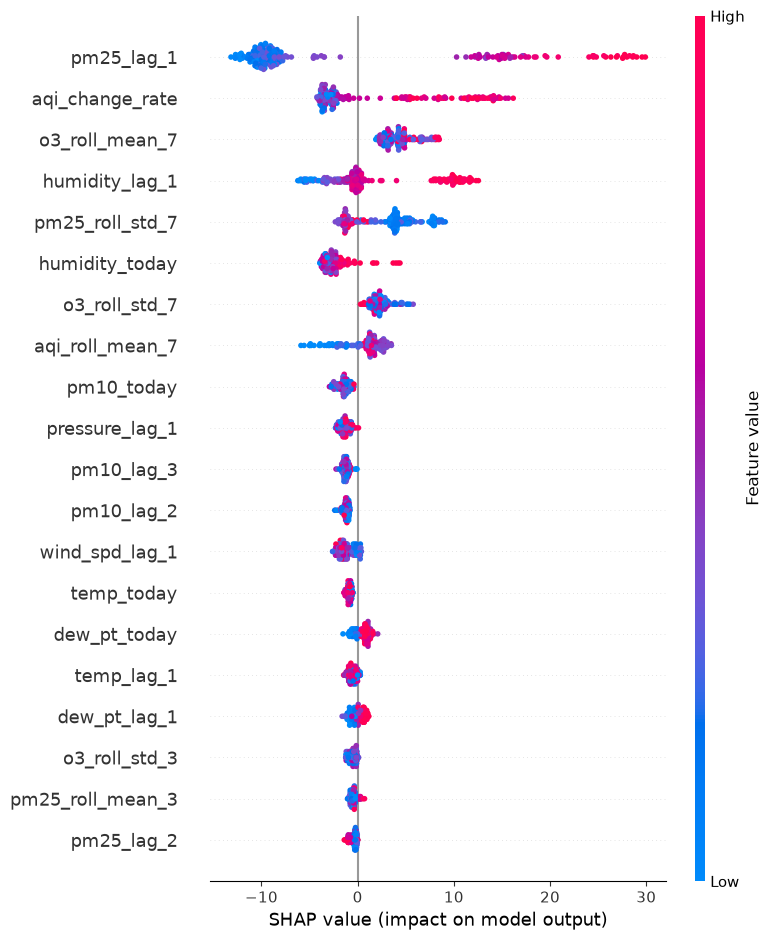

C:\Users\Lucky\AppData\Local\Temp\ipykernel_4644\633004850.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


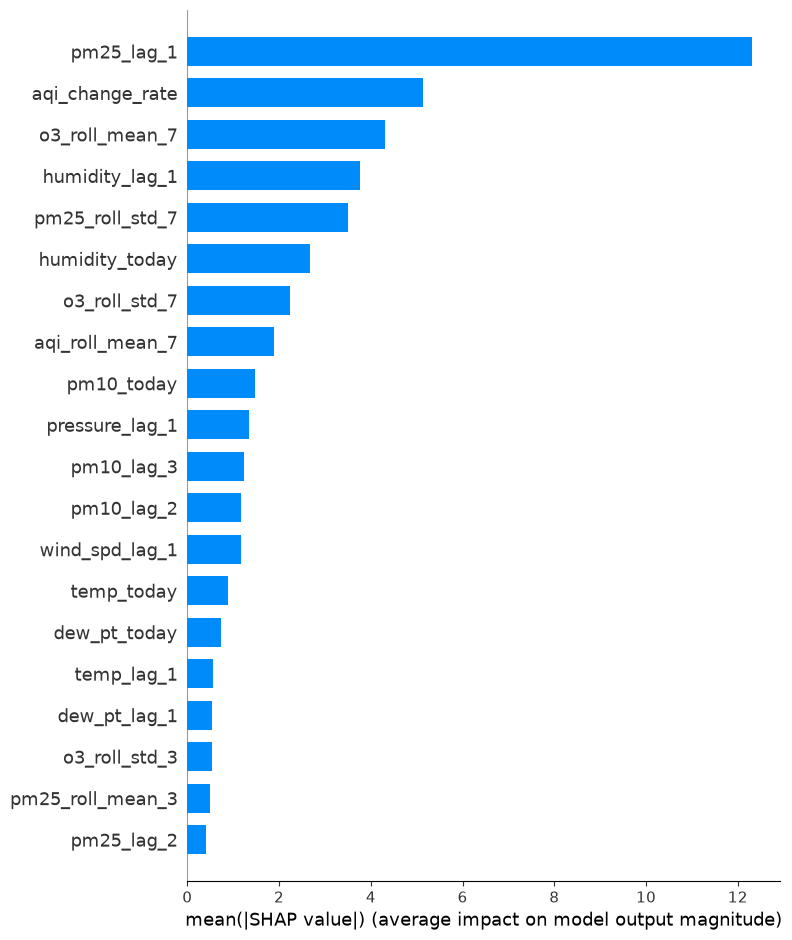

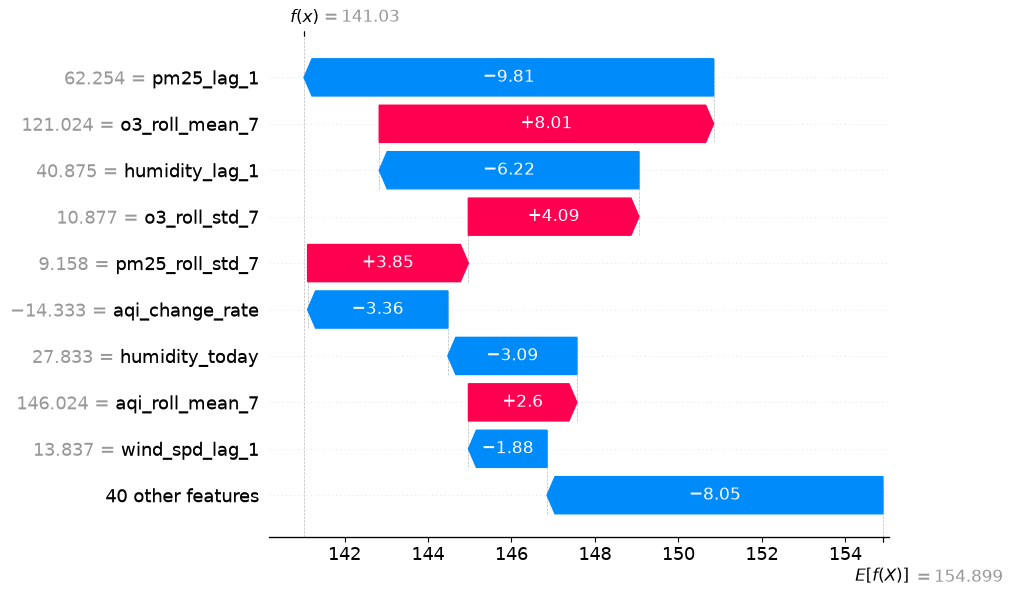

In [34]:
get_shap(ALL_TRAINING_FEATURES, best_model_random_forest)